In [ ]:
import numpy as np


def psi(r, b, phi0=0):
    """Calcola il potenziale relativo (G=1, M=1)"""
    phi = -1 / np.sqrt(r**2 + b**2)
    return -phi + phi0

def generate_treecode_ic(filename, X_M, v_M, N=10000, b=1.0, mass_M=0.05):
    """
    Genera le Condizioni Iniziali per il Treecode: 
    Background di Plummer in equilibrio + 1 Perturbatore Massiccio.
    """
    xM, yM, zM = X_M
    vxM, vyM, vzM = v_M
    
    # Riproporziona le masse del background in modo che M_tot = 1.0 (incluso il buco nero)
    masses = (np.ones(N-1) - mass_M) / (N-1) 

    # --- CAMPIONAMENTO SPAZIALE DEL BACKGROUND ---
    phi = np.random.uniform(0, 2*np.pi, N-1)
    costheta = np.random.uniform(-1, 1, N-1)
    u = np.random.uniform(0, 1, N-1)
    
    theta = np.arccos(costheta)
    # Inversione della massa racchiusa per trovare i raggi
    r = np.sqrt(b**2 * u**(2/3) / (1 - u**(2/3)))

    x = r * np.sin(theta) * np.cos(phi)
    y = r * np.sin(theta) * np.sin(phi)
    z = r * np.cos(theta)

    # --- CAMPIONAMENTO DELLE VELOCITÀ (Rejection Sampling Vettorizzato) ---
    f = lambda q: (1 - q**2)**(7/2) * q**2
    ymax = 0.1
    q = np.array([])

    print("Campionamento termodinamico del background in corso...")
    # Estraiamo a blocchi di 1000 per rendere lo script super veloce
    while len(q) < (N-1):
        x_rej = np.random.uniform(0, 1, 1000) 
        y_rej = np.random.uniform(0, ymax, 1000)
        valid = x_rej[y_rej < f(x_rej)]
        q = np.append(q, valid)
    
    q = q[:N-1] # Troncato alla lunghezza esatta necessaria
    v = q * np.sqrt(2 * psi(r, b))

    # Direzioni casuali isotrope per le velocità
    phi_v = np.random.uniform(0, 2*np.pi, N-1)
    costheta_v = np.random.uniform(-1, 1, N-1)    
    theta_v = np.arccos(costheta_v)
    
    vx = v * np.sin(theta_v) * np.cos(phi_v)
    vy = v * np.sin(theta_v) * np.sin(phi_v)
    vz = v * np.cos(theta_v)

    # --- SCRITTURA DEL FILE PER IL TREECODE ---
    print(f"Scrittura file '{filename}'...")
    with open(filename, 'w') as f_out:
        f_out.write(f"{N}\n")         # Npart totali (Perturbatore + background)
        f_out.write("3\n")            # Dimensioni spaziali
        f_out.write("0.0\n")          # Tempo di partenza (t=0)
        
        # Array delle masse (indice 0 = buco nero)
        f_out.write(f"{mass_M:.8e}\n")
        for m in masses:
            f_out.write(f"{m:.8e}\n")
            
        # Array delle posizioni (indice 0 = buco nero)
        f_out.write(f"{xM:.8e} {yM:.8e} {zM:.8e}\n")
        for i in range(N-1):
            f_out.write(f"{x[i]:.8e} {y[i]:.8e} {z[i]:.8e}\n")
            
        # Array delle velocità (indice 0 = buco nero)
        f_out.write(f"{vxM:.8e} {vyM:.8e} {vzM:.8e}\n")
        for i in range(N-1):
            f_out.write(f"{vx[i]:.8e} {vy[i]:.8e} {vz[i]:.8e}\n")

    print("Generazione IC completata con successo! Pronti per il Treecode.")
    return True


if __name__ == "__main__":
    
    # Parametri del sistema
    N_part = 10000
    M_p = 0.05    # La tua massa perturbativa al 5%
    b_scale = 1.0 # Raggio di scala Plummer
    G_M = 1.0     # Costante gravitazionale * Massa totale (N-body units)
    
    # SETUP INIZIALE: Raggio teorico
    r_start = 2.0
    
    # Calcolo rigoroso della velocità circolare del Plummer:
    # v_c = sqrt(GM * r^2 / (r^2 + b^2)^(3/2)) = sqrt(GM) * r / (r^2 + b^2)^(3/4)
    v_circ = np.sqrt(G_M) * r_start / (r_start**2 + b_scale**2)**0.75
    
    print(f"Target Sperimentale -> Raggio: {r_start}, Velocità Circolare: {v_circ:.5f}")
    
    # Piazziamo il buco nero sull'asse X
    X_BH = [r_start, 0.0, 0.0]
    
    # Sparato lungo l'asse Y per innescare un'orbita circolare perfetta sul piano XY
    V_BH = [0.0, v_circ, 0.0]
    
    # Genera il file
    output_filename = 'C:/Users/user/OneDrive/Documenti/Astro/dynamics_of_stellar_systems/Friction/IC_Matteo_Circular_R2.txt'
    
    generate_treecode_ic(filename=output_filename, 
                         X_M=X_BH, 
                         v_M=V_BH, 
                         N=N_part, 
                         b=b_scale, 
                         mass_M=M_p)

Target Sperimentale -> Raggio: 2.0, Velocità Circolare: 0.59814
Campionamento termodinamico del background in corso...
Scrittura file 'C:/Users/user/OneDrive/Documenti/Astro/dynamics_of_stellar_systems/Friction/IC_Matteo_Circular_R2.txt'...
Generazione IC completata con successo! Pronti per il Treecode.


`treecode.exe in=C:/Users/user/OneDrive/Documenti/Astro/dynamics_of_stellar_systems/Friction
/IC_Matteo_Circular_R2.txt out=out_IC.txt dtime=0.01 tstop=30.0 theta=0.5 eps=0.05 dtout=0.1 > logfile_IC.txt` 

<>:131: SyntaxWarning: invalid escape sequence '\l'
<>:131: SyntaxWarning: invalid escape sequence '\l'
C:\Users\user\AppData\Local\Temp\ipykernel_3772\1522204128.py:131: SyntaxWarning: invalid escape sequence '\l'
  ax1.text(ts[-1]*0.05, 0.3, 'Palude Viscosa ($X \ll 1$)', fontsize=10, color='darkblue')


Lettura del file di output in corso...
✅ Totale snapshot caricati: 602
Calcolo del centro di densità iterativo per ogni frame (ci vorrà qualche secondo)...
Elaborazione completata! Avvio della dashboard diagnostica...


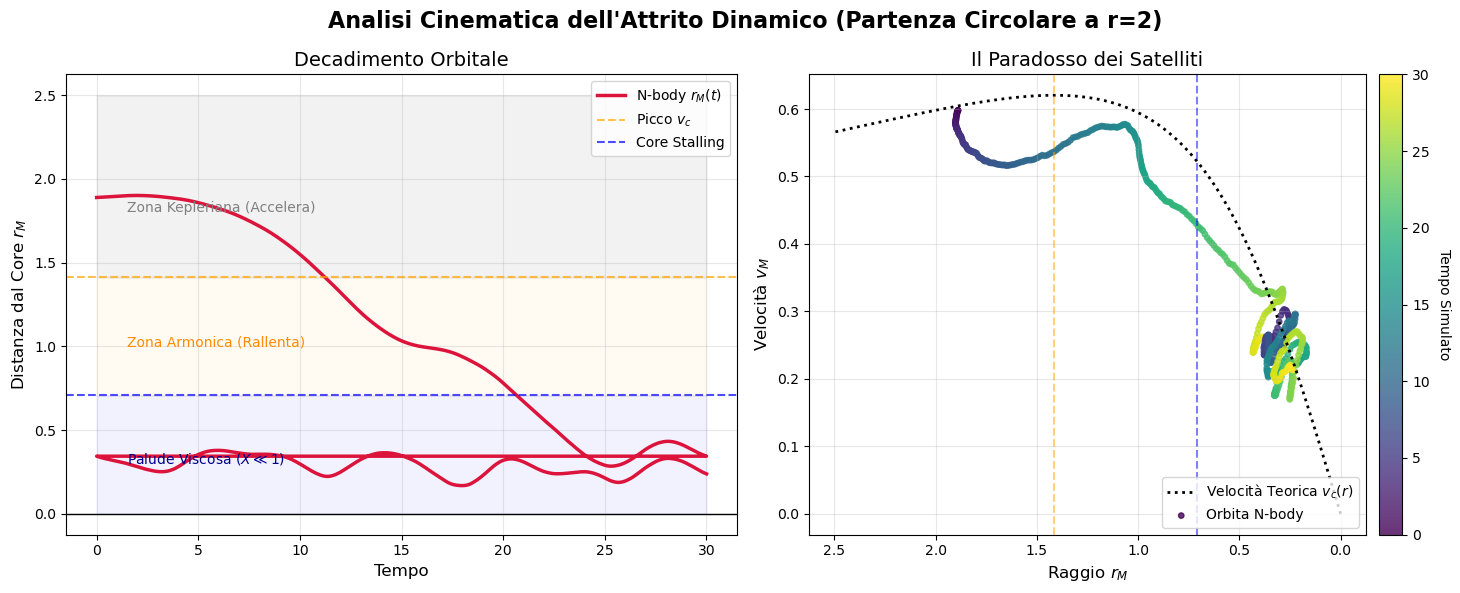

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


def load_all_snapshots(filename, N=10000):
    snapshots = []
    with open(filename, 'r') as f:
        # Leggiamo tutto e puliamo da righe vuote
        lines = [l.strip() for l in f.readlines() if l.strip()]
    
    i = 0
    total_lines = len(lines)
    lines_per_snapshot = 3 + 3 * N
    
    while i + lines_per_snapshot <= total_lines:
        try:
            n_particles = float(lines[i])
            if n_particles != N:
                print(f"Attenzione: trovato N={n_particles} alla riga {i}, atteso {N}")
                i += 1
                continue
                
            t_now = float(lines[i+2])
            m_start = i + 3
            p_start = m_start + N
            v_start = p_start + N
            
            m = np.array(lines[m_start : p_start], dtype=float)
            pos = np.array([l.split() for l in lines[p_start : v_start]], dtype=float)
            vel = np.array([l.split() for l in lines[v_start : v_start + N]], dtype=float)
            
            snapshots.append({'time': t_now, 'm': m, 'pos': pos, 'vel': vel})
            i += lines_per_snapshot
            
        except Exception as e:
            print(f"Errore alla riga {i}: {e}")
            i += 1
            
    if not snapshots:
        print("❌ Nessuno snapshot salvato. Verifica che N sia corretto.")
    else:
        print(f"✅ Totale snapshot caricati: {len(snapshots)}")
        
    return snapshots

def find_density_center(pos, m, factor=0.9, tol=1e-5, min_particles=100):
    """Trova il centro di densità restringendo iterativamente la sfera."""
    current_cm = np.sum(pos * m[:, np.newaxis], axis=0) / np.sum(m)
    distances = np.linalg.norm(pos - current_cm, axis=1)
    current_r = np.max(distances)
    diff = 1e10
    
    while diff > tol and len(pos) > min_particles:
        old_cm = current_cm.copy()
        current_r *= factor
        
        distances = np.linalg.norm(pos - current_cm, axis=1)
        mask = distances < current_r
        
        if np.sum(mask) < min_particles:
            break
            
        pos_subset = pos[mask]
        m_subset = m[mask]
        current_cm = np.sum(pos_subset * m_subset[:, np.newaxis], axis=0) / np.sum(m_subset)
        diff = np.linalg.norm(current_cm - old_cm)
        
    return current_cm


percorso_out = r"C:/Users/user/Downloads/treecode/out_IC.txt"

print("Lettura del file di output in corso...")
frames = load_all_snapshots(percorso_out, N=10000)

# Verifichiamo che i dati ci siano prima di procedere
if len(frames) > 0:
   
    print("Calcolo del centro di densità iterativo per ogni frame (ci vorrà qualche secondo)...")
    cm = []
    for snap in frames:
        pos = snap['pos']
        m = snap['m']
        center = find_density_center(pos, m)
        cm.append(center)
    
    cm = np.array(cm)
    
   
    print("Elaborazione completata! Avvio della dashboard diagnostica...")
    
    # ESTRAZIONE DATI BUCO NERO (Indice 0)
    ts = np.array([snap['time'] for snap in frames])
    pos_BH = np.array([snap['pos'][0] for snap in frames])
    vel_BH = np.array([snap['vel'][0] for snap in frames])
    
    # CALCOLO RELATIVO AL CORE
    r_M = np.linalg.norm(pos_BH - cm, axis=1)
    v_M = np.linalg.norm(vel_BH, axis=1) 
    
    # CURVE TEORICHE
    b = 1.0
    GM = 1.0
    
    # --- DASHBOARD PLOT ---
    fig, axs = plt.subplots(1, 2, figsize=(15, 6))
    fig.suptitle('Analisi Cinematica dell\'Attrito Dinamico (Partenza Circolare a r=2)', fontsize=16, fontweight='bold')
    
    # PLOT 1: DECADIMENTO ORBITALE
    ax1 = axs[0]
    ax1.plot(ts, r_M, color='crimson', lw=2.5, label='N-body $r_M(t)$')
    ax1.axhline(1.414, color='orange', linestyle='--', alpha=0.7, label=r'Picco $v_c$')
    ax1.axhline(0.707, color='blue', linestyle='--', alpha=0.7, label=r'Core Stalling')
    ax1.axhline(0.0, color='black', lw=1)
    
    ax1.fill_between(ts, 1.414, 2.5, color='gray', alpha=0.1)
    ax1.text(ts[-1]*0.05, 1.8, 'Zona Kepleriana (Accelera)', fontsize=10, color='gray')
    ax1.fill_between(ts, 0.707, 1.414, color='orange', alpha=0.05)
    ax1.text(ts[-1]*0.05, 1.0, 'Zona Armonica (Rallenta)', fontsize=10, color='darkorange')
    ax1.fill_between(ts, 0.0, 0.707, color='blue', alpha=0.05)
    ax1.text(ts[-1]*0.05, 0.3, 'Palude Viscosa ($X \ll 1$)', fontsize=10, color='darkblue')
    
    ax1.set_xlabel('Tempo', fontsize=12)
    ax1.set_ylabel('Distanza dal Core $r_M$', fontsize=12)
    ax1.set_title('Decadimento Orbitale', fontsize=14)
    ax1.legend(loc='upper right')
    ax1.grid(True, alpha=0.3)
    
    # PLOT 2: SPAZIO DELLE FASI (IL PARADOSSO)
    ax2 = axs[1]
    r_teorico = np.linspace(0, 2.5, 500)
    v_teorico = np.sqrt(GM) * r_teorico / (r_teorico**2 + b**2)**0.75
    ax2.plot(r_teorico, v_teorico, color='black', linestyle=':', lw=2, label='Velocità Teorica $v_c(r)$')
    
    scatter = ax2.scatter(r_M, v_M, c=ts, cmap='viridis', s=15, alpha=0.8, label='Orbita N-body')
    ax2.axvline(1.414, color='orange', linestyle='--', alpha=0.5)
    ax2.axvline(0.707, color='blue', linestyle='--', alpha=0.5)
    
    ax2.set_xlabel('Raggio $r_M$', fontsize=12)
    ax2.set_ylabel('Velocità $v_M$', fontsize=12)
    ax2.set_title('Il Paradosso dei Satelliti', fontsize=14)
    ax2.legend(loc='lower right')
    ax2.grid(True, alpha=0.3)
    ax2.invert_xaxis()
    
    cbar = fig.colorbar(scatter, ax=ax2, pad=0.02)
    cbar.set_label('Tempo Simulato', rotation=270, labelpad=15)
    
    plt.tight_layout()
    plt.show()
else:
    print("Nessun dato su cui plottare. Controlla il percorso del file!")

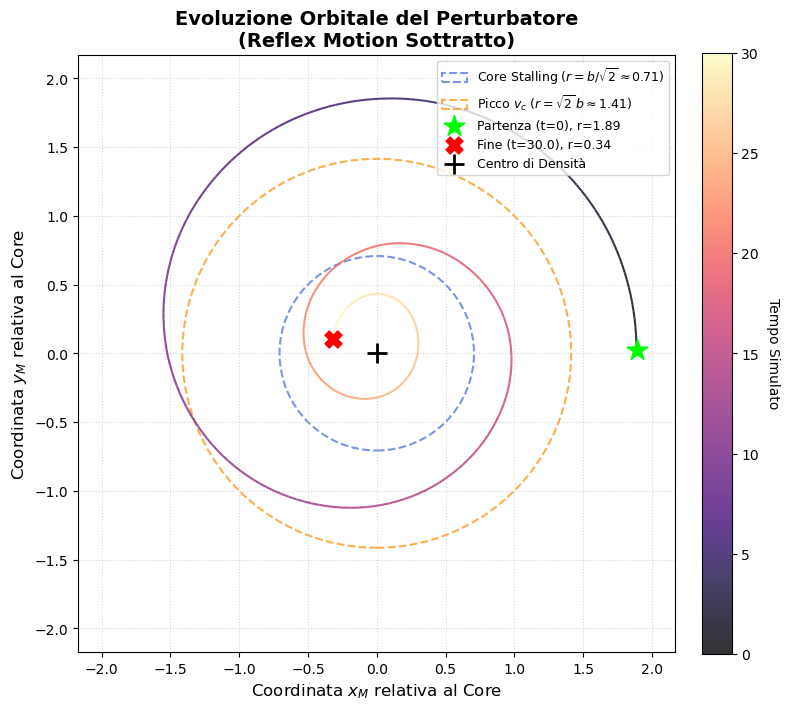

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection


# 1. Depurazione dal Reflex Motion
x_rel = pos_BH[:, 0] - cm[:, 0]
y_rel = pos_BH[:, 1] - cm[:, 1]
z_rel = pos_BH[:, 2] - cm[:, 2]

# 2. Setup del grafico
fig, ax = plt.subplots(figsize=(8, 8))
ax.set_aspect('equal')

# 3. Creazione della linea sfumata nel tempo
points = np.array([x_rel, y_rel]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

norm = plt.Normalize(ts.min(), ts.max())
lc = LineCollection(segments, cmap='magma', norm=norm, alpha=0.8, lw=1.5)

# FIX CRITICO: segments ha N-1 elementi, ts ha N elementi.
# Bisogna passare ts[:-1] (o la media ts[:-1]+ts[1:])/2) altrimenti
# matplotlib riceve un array di lunghezza sbagliata → colori scorretti o errore.
lc.set_array(ts[:-1])  # ← CORRETTO (era: lc.set_array(ts))

line = ax.add_collection(lc)

# 4. Marcatori fisici
# Plummer b=1: il picco di v_c è a r = b/sqrt(2) ≈ 0.707
# L'altra soglia importante è r = sqrt(2)*b ≈ 1.414 (zona kepleriana)
core_circle = plt.Circle(
    (0, 0), 0.707,
    color='royalblue', fill=False, linestyle='--', lw=1.5, alpha=0.7,
    label=r'Core Stalling ($r = b/\sqrt{2} \approx 0.71$)'
)
kep_circle = plt.Circle(
    (0, 0), 1.414,
    color='darkorange', fill=False, linestyle='--', lw=1.5, alpha=0.7,
    label=r'Picco $v_c$ ($r = \sqrt{2}\,b \approx 1.41$)'
)
ax.add_patch(core_circle)
ax.add_patch(kep_circle)

# Punto di partenza e centro di densità
ax.scatter(x_rel[0], y_rel[0], color='lime', marker='*', s=250, zorder=5,
           label=f'Partenza (t=0), r={np.hypot(x_rel[0], y_rel[0]):.2f}')
ax.scatter(x_rel[-1], y_rel[-1], color='red', marker='X', s=150, zorder=5,
           label=f'Fine (t={ts[-1]:.1f}), r={np.hypot(x_rel[-1], y_rel[-1]):.2f}')
ax.scatter(0, 0, color='black', marker='+', s=200, linewidths=2, zorder=5,
           label='Centro di Densità')

# 5. Limiti assi
# FIX: usiamo il massimo tra le due coordinate per avere un quadrato centrato
lim = max(np.max(np.abs(x_rel)), np.max(np.abs(y_rel))) * 1.15
ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)

ax.set_xlabel(r'Coordinata $x_M$ relativa al Core', fontsize=12)
ax.set_ylabel(r'Coordinata $y_M$ relativa al Core', fontsize=12)
ax.set_title("Evoluzione Orbitale del Perturbatore\n(Reflex Motion Sottratto)", fontsize=14, fontweight='bold')

cbar = fig.colorbar(line, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Tempo Simulato', rotation=270, labelpad=15)

ax.legend(loc='upper right', fontsize=9)
ax.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()


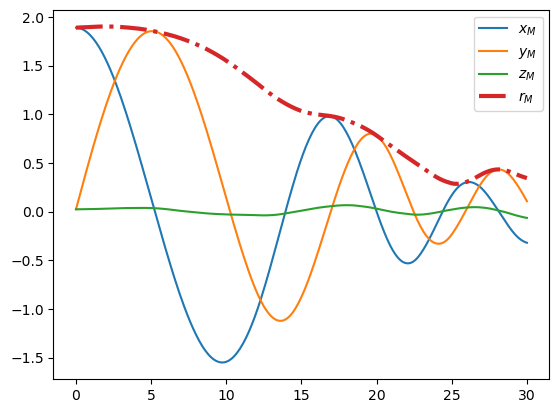

In [10]:
plt.plot(ts, x_rel, label=r'$x_M$')
plt.plot(ts, y_rel, label=r'$y_M$')
plt.plot(ts, z_rel, label=r'$z_M$')
plt.plot(ts, np.sqrt(x_rel**2+y_rel**2+z_rel**2), label=r'$r_M$',ls='-.',lw=3)

plt.legend();

In [16]:
xfin = frames[-1]['pos'][:,0]
yfin = frames[-1]['pos'][:,1]
zfin = frames[-1]['pos'][:,2]

vxfin = frames[-1]['vel'][:,0]
vyfin = frames[-1]['vel'][:,1]
vzfin = frames[-1]['vel'][:,2]

In [17]:
mass_M = 0.05
masses = (np.ones(10000-1)-mass_M)/(10000-1) #total mass 1
with open('C:/Users/user/OneDrive/Documenti/Astro/dynamics_of_stellar_systems/Friction/IC_df2.txt', 'w') as f:
    f.write(f"{10000}\n")         # Npart
    f.write("3\n")            # N of dimensions
    f.write("0.0\n")          # time
    
    # Array of masses
    f.write(f"{mass_M:.8e}\n")
    for m in masses:
        f.write(f"{m:.8e}\n")
        
    # Array of positions
    
    for i in range(10000):
        f.write(f"{xfin[i]:.8e} {yfin[i]:.8e} {zfin[i]:.8e}\n")
        
    # Array of velocities
    for i in range(10000):
        f.write(f"{vxfin[i]:.8e} {vyfin[i]:.8e} {vzfin[i]:.8e}\n")

In [32]:
def load_all_snapshots_multi_run(filename, N=10000):
    """
    Gestisce output files con più run concatenate (es. t:0→30, 0→30).
    Rileva automaticamente i reset del tempo e aggiunge l'offset cumulativo.
    """
    with open(filename, 'r') as f:
        lines = [l.strip() for l in f.readlines() if l.strip()]
    
    lines_per_snapshot = 3 + 3 * N
    n_snaps = len(lines) // lines_per_snapshot
    print(f"Snapshot totali nel file: {n_snaps}")
    
    snapshots  = []
    t_offset   = 0.0   # offset cumulativo tra run successive
    t_previous = -1.0  # tempo dell'ultimo snapshot letto
    
    for k in range(n_snaps):
        i = k * lines_per_snapshot
        try:
            t_now_raw = float(lines[i + 2])   # tempo grezzo scritto dal treecode
            
            # --- RILEVAMENTO RESET ---
            # Se il tempo torna indietro rispetto al frame precedente, 
            # significa che è iniziata una nuova run → aggiorna l'offset
            if t_now_raw < t_previous:
                t_offset += t_previous        # somma il tempo finale della run precedente
                print(f"  → Reset rilevato al frame {k}: "
                      f"t_raw={t_now_raw:.2f}, nuovo offset={t_offset:.2f}")
            
            t_corrected = t_now_raw + t_offset  # tempo assoluto corretto
            t_previous  = t_now_raw
            
            m_start = i + 3
            p_start = m_start + N
            v_start = p_start + N
            
            m   = np.array(lines[m_start:p_start], dtype=float)
            pos = np.array([l.split() for l in lines[p_start:v_start]], dtype=float)
            vel = np.array([l.split() for l in lines[v_start:v_start+N]], dtype=float)
            
            snapshots.append({'time': t_corrected, 'm': m, 'pos': pos, 'vel': vel})
            
        except Exception as e:
            print(f"Errore al frame {k}: {e}")
    
    ts_all = [s['time'] for s in snapshots]
    print(f"✅ Caricati {len(snapshots)} snapshot | t: {ts_all[0]:.2f} → {ts_all[-1]:.2f}")
    return snapshots


# --- USO ---
frames_all = load_all_snapshots_multi_run(
    r"C:\Users\user\Downloads\treecode\out_IC.txt",
    N=10000
)


Snapshot totali nel file: 602
  → Reset rilevato al frame 301: t_raw=0.00, nuovo offset=30.00
✅ Caricati 602 snapshot | t: 0.00 → 60.00


Calcolo centro di densità per ogni frame...


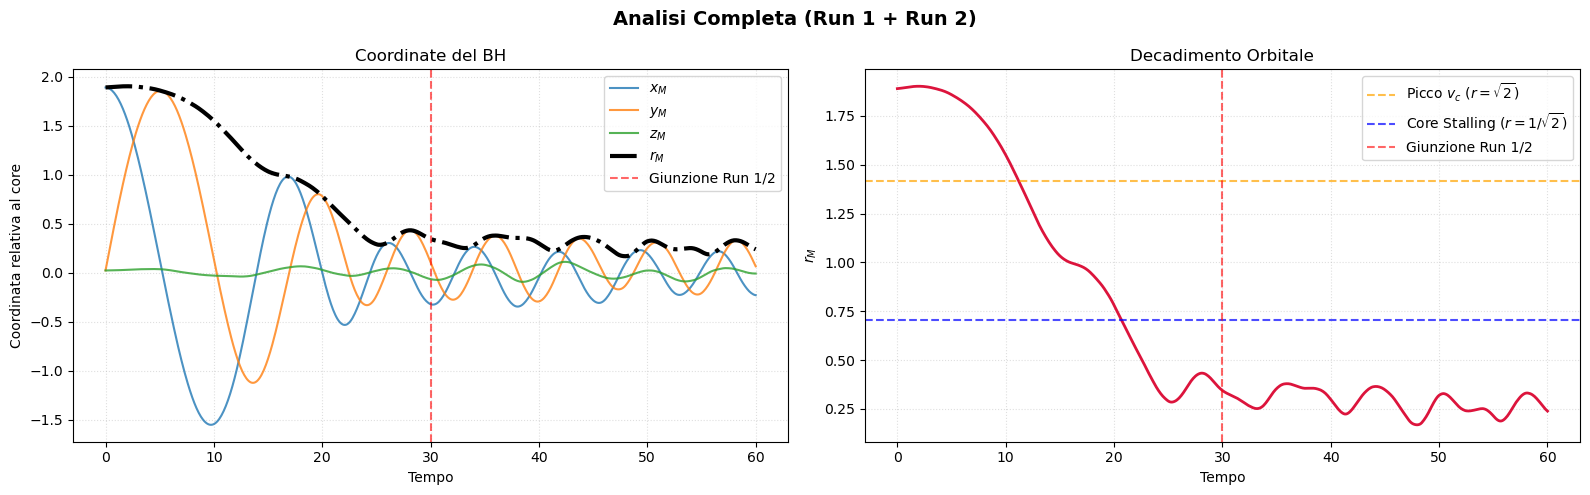

In [33]:
# ====================================================================
# 1. ESTRAZIONE DATI
# ====================================================================
ts     = np.array([snap['time'] for snap in frames_all])
pos_BH = np.array([snap['pos'][0] for snap in frames_all])
vel_BH = np.array([snap['vel'][0] for snap in frames_all])

# ====================================================================
# 2. CENTRO DI DENSITÀ (reflex motion)
# ====================================================================
print("Calcolo centro di densità per ogni frame...")
cm = np.array([find_density_center(snap['pos'], snap['m']) for snap in frames_all])

# ====================================================================
# 3. COORDINATE RELATIVE AL CORE
# ====================================================================
x_rel = pos_BH[:, 0] - cm[:, 0]
y_rel = pos_BH[:, 1] - cm[:, 1]
z_rel = pos_BH[:, 2] - cm[:, 2]
r_M   = np.sqrt(x_rel**2 + y_rel**2 + z_rel**2)
v_M   = np.linalg.norm(vel_BH, axis=1)

# ====================================================================
# 4. PLOT
# ====================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Analisi Completa (Run 1 + Run 2)', fontsize=14, fontweight='bold')

# --- Coordinate vs tempo ---
ax1 = axes[0]
ax1.plot(ts, x_rel, label=r'$x_M$', alpha=0.8)
ax1.plot(ts, y_rel, label=r'$y_M$', alpha=0.8)
ax1.plot(ts, z_rel, label=r'$z_M$', alpha=0.8)
ax1.plot(ts, r_M,   label=r'$r_M$', ls='-.', lw=3, color='black')
ax1.axvline(30.0, color='red', ls='--', lw=1.5, alpha=0.6, label='Giunzione Run 1/2')
ax1.set_xlabel('Tempo')
ax1.set_ylabel('Coordinata relativa al core')
ax1.set_title('Coordinate del BH')
ax1.legend()
ax1.grid(True, linestyle=':', alpha=0.4)

# --- Decadimento orbitale ---
ax2 = axes[1]
ax2.plot(ts, r_M, color='crimson', lw=2)
ax2.axhline(1.414, color='orange', ls='--', alpha=0.7, label=r'Picco $v_c$ ($r=\sqrt{2}$)')
ax2.axhline(0.707, color='blue',   ls='--', alpha=0.7, label=r'Core Stalling ($r=1/\sqrt{2}$)')
ax2.axvline(30.0,  color='red',    ls='--', lw=1.5, alpha=0.6, label='Giunzione Run 1/2')
ax2.set_xlabel('Tempo')
ax2.set_ylabel(r'$r_M$')
ax2.set_title('Decadimento Orbitale')
ax2.legend()
ax2.grid(True, linestyle=':', alpha=0.4)

plt.tight_layout()
plt.show()


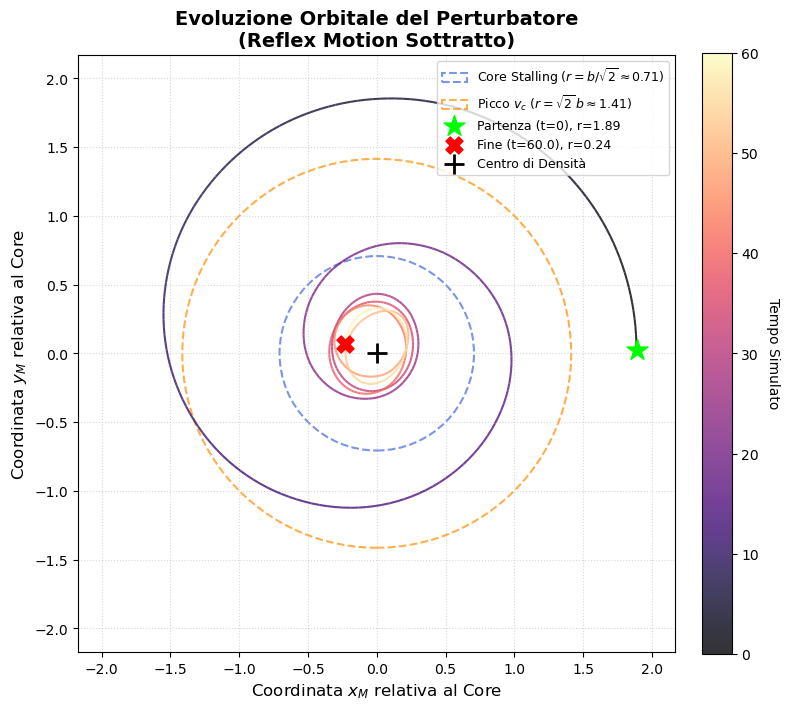

In [34]:
# 2. Setup del grafico
fig, ax = plt.subplots(figsize=(8, 8))
ax.set_aspect('equal')

# 3. Creazione della linea sfumata nel tempo
points = np.array([x_rel, y_rel]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

norm = plt.Normalize(ts.min(), ts.max())
lc = LineCollection(segments, cmap='magma', norm=norm, alpha=0.8, lw=1.5)

# FIX CRITICO: segments ha N-1 elementi, ts ha N elementi.
# Bisogna passare ts[:-1] (o la media ts[:-1]+ts[1:])/2) altrimenti
# matplotlib riceve un array di lunghezza sbagliata → colori scorretti o errore.
lc.set_array(ts[:-1])  # ← CORRETTO (era: lc.set_array(ts))

line = ax.add_collection(lc)

# 4. Marcatori fisici
# Plummer b=1: il picco di v_c è a r = b/sqrt(2) ≈ 0.707
# L'altra soglia importante è r = sqrt(2)*b ≈ 1.414 (zona kepleriana)
core_circle = plt.Circle(
    (0, 0), 0.707,
    color='royalblue', fill=False, linestyle='--', lw=1.5, alpha=0.7,
    label=r'Core Stalling ($r = b/\sqrt{2} \approx 0.71$)'
)
kep_circle = plt.Circle(
    (0, 0), 1.414,
    color='darkorange', fill=False, linestyle='--', lw=1.5, alpha=0.7,
    label=r'Picco $v_c$ ($r = \sqrt{2}\,b \approx 1.41$)'
)
ax.add_patch(core_circle)
ax.add_patch(kep_circle)

# Punto di partenza e centro di densità
ax.scatter(x_rel[0], y_rel[0], color='lime', marker='*', s=250, zorder=5,
           label=f'Partenza (t=0), r={np.hypot(x_rel[0], y_rel[0]):.2f}')
ax.scatter(x_rel[-1], y_rel[-1], color='red', marker='X', s=150, zorder=5,
           label=f'Fine (t={ts[-1]:.1f}), r={np.hypot(x_rel[-1], y_rel[-1]):.2f}')
ax.scatter(0, 0, color='black', marker='+', s=200, linewidths=2, zorder=5,
           label='Centro di Densità')

# 5. Limiti assi
# FIX: usiamo il massimo tra le due coordinate per avere un quadrato centrato
lim = max(np.max(np.abs(x_rel)), np.max(np.abs(y_rel))) * 1.15
ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)

ax.set_xlabel(r'Coordinata $x_M$ relativa al Core', fontsize=12)
ax.set_ylabel(r'Coordinata $y_M$ relativa al Core', fontsize=12)
ax.set_title("Evoluzione Orbitale del Perturbatore\n(Reflex Motion Sottratto)", fontsize=14, fontweight='bold')

cbar = fig.colorbar(line, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Tempo Simulato', rotation=270, labelpad=15)

ax.legend(loc='upper right', fontsize=9)
ax.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()


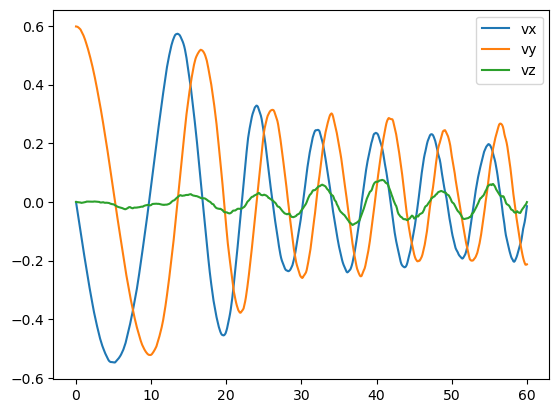

In [36]:
plt.plot(ts,(vel_BH[:,0]), label='vx')
plt.plot(ts,(vel_BH[:,1]), label='vy')
plt.plot(ts,(vel_BH[:,2]), label='vz')
plt.legend()
plt.show()